---
### Agglomerative hierarchical clustering.
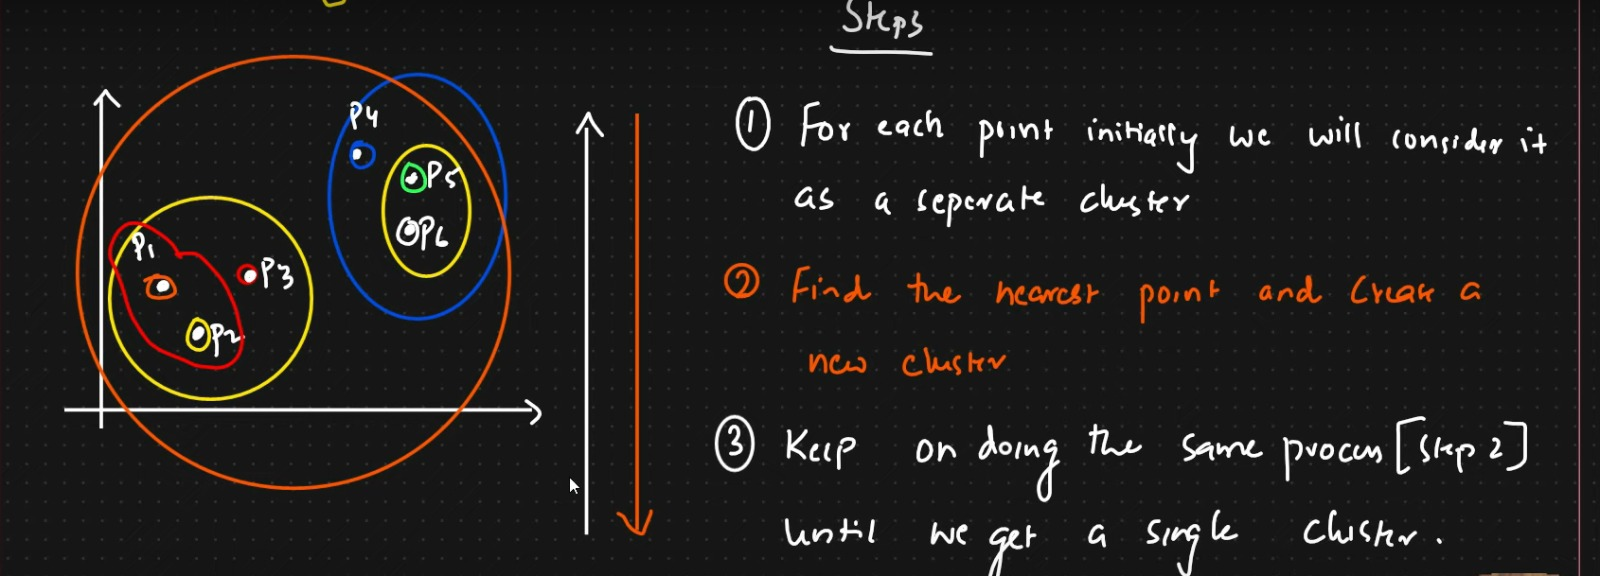

---

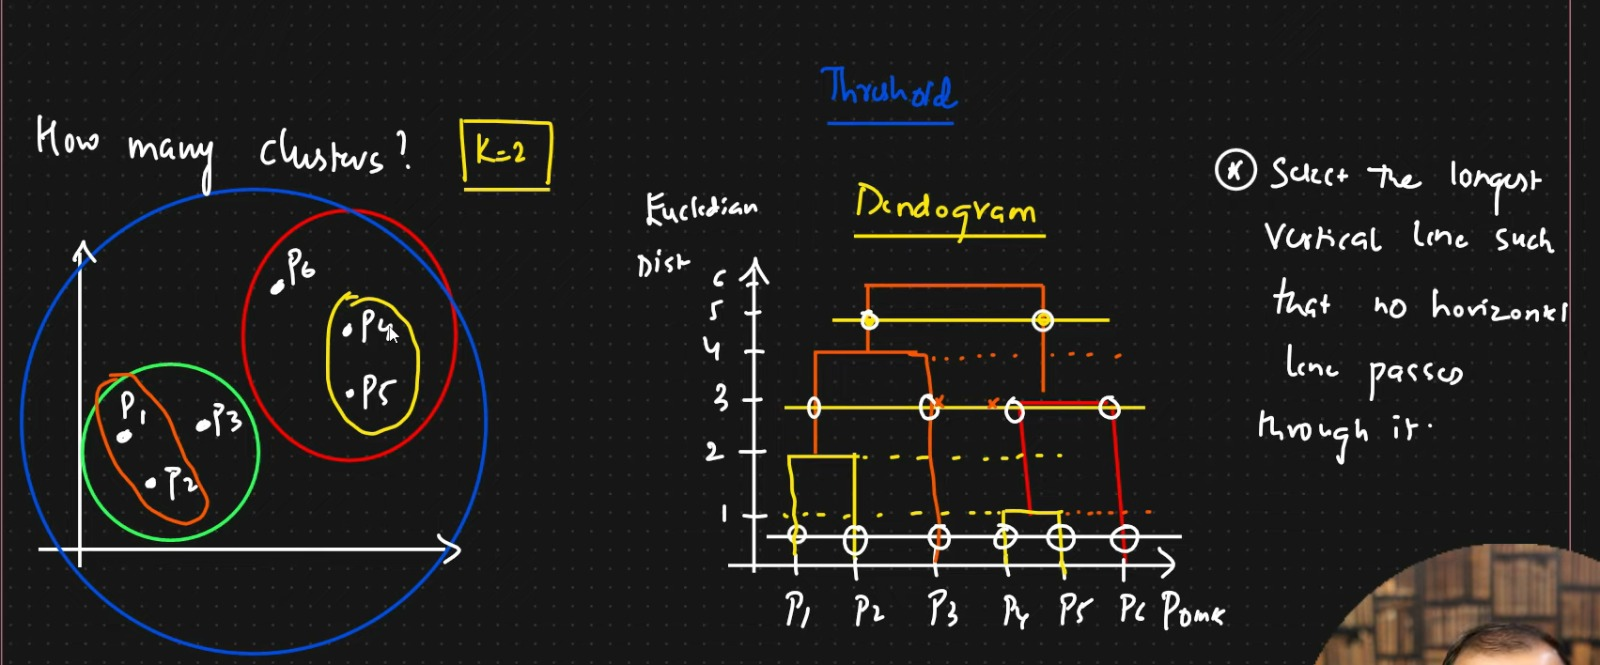

 ---
 
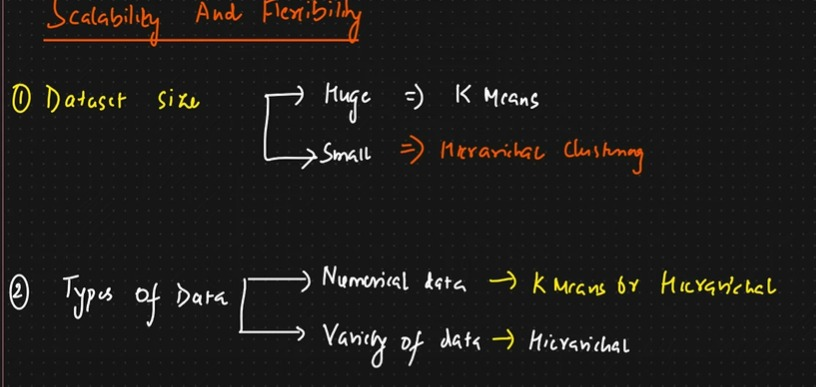

---

## Implementation of partition-based clustering (K-MEANS).

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [6]:
X, y = make_blobs(n_samples=1000, n_features= 2, centers=3, random_state=452)

In [7]:
X.shape

(1000, 2)

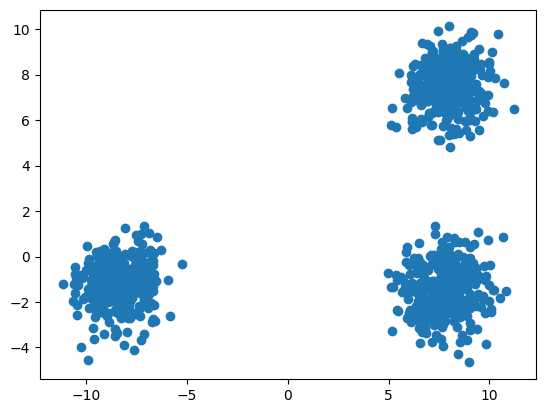

In [10]:
plt.scatter(X[:,0], X[:,1]);

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.22, random_state=452
)

In [13]:
X_train.shape

(780, 2)

In [14]:
from sklearn.cluster import KMeans

In [15]:
# finding Within Cluster Sum of Squares for ELBOW METHOD.

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init= "k-means++")
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [16]:
wcss

[60860.59777118052,
 12192.772554071138,
 1663.8417443205697,
 1468.2964438491952,
 1276.9697914868002,
 1070.8549097168575,
 1032.475002229401,
 853.0033932774556,
 816.9924435178293,
 752.6944643576262]

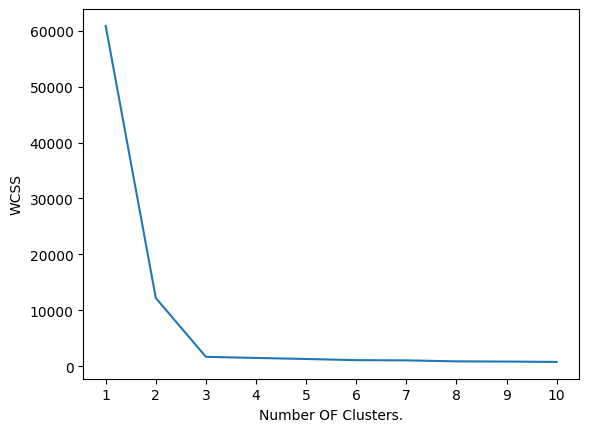

In [19]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number OF Clusters.")
plt.ylabel("WCSS")
plt.show()

In [21]:
kmeans = KMeans(n_clusters=3, init= "k-means++")
y_labels = kmeans.fit_predict(X_train)

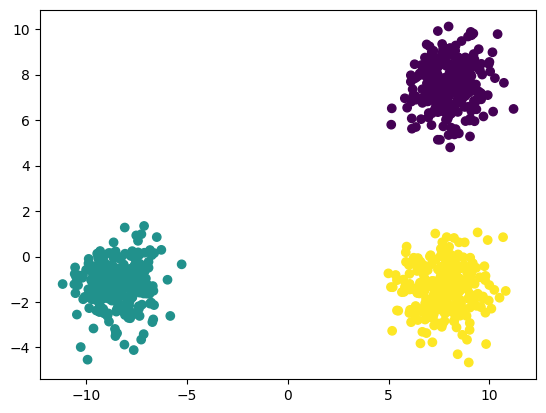

In [22]:
plt.scatter(X_train[:,0], X_train[:,1], c= y_labels);

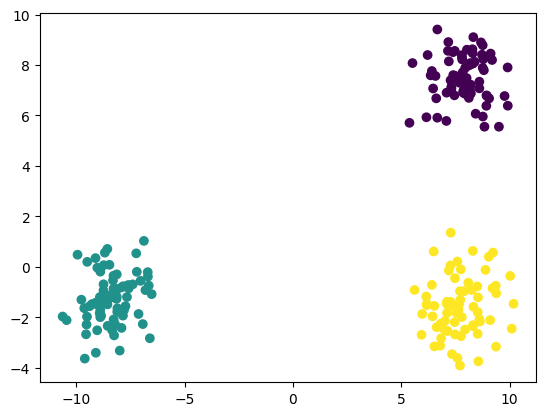

In [25]:
y_test_label = kmeans.predict(X_test)
plt.scatter(X_test[:,0], X_test[:,1], c= y_test_label);

## Heirarchihcal Clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [2]:
iris = datasets.load_iris()

In [7]:
iris_data = pd.DataFrame(iris.data)

In [8]:
iris_data.columns = iris.feature_names

In [9]:
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [11]:
X_scaled = scaler.fit_transform(iris_data)

In [13]:
X_scaled.shape

(150, 4)

In [14]:
## PCA
from sklearn.decomposition import PCA
pca = PCA(n_components= 2)

In [15]:
scaled_pca_data = pca.fit_transform(X_scaled)

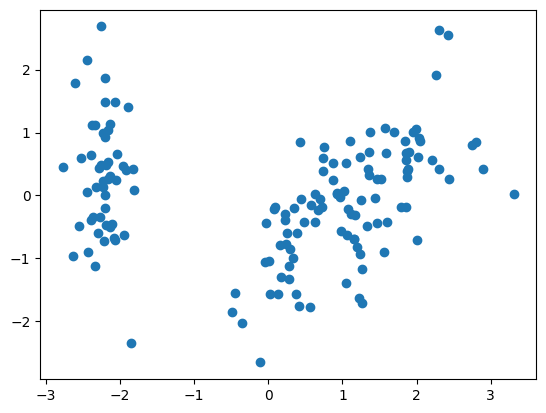

In [18]:
plt.scatter(scaled_pca_data[:,0], scaled_pca_data[:,1]);

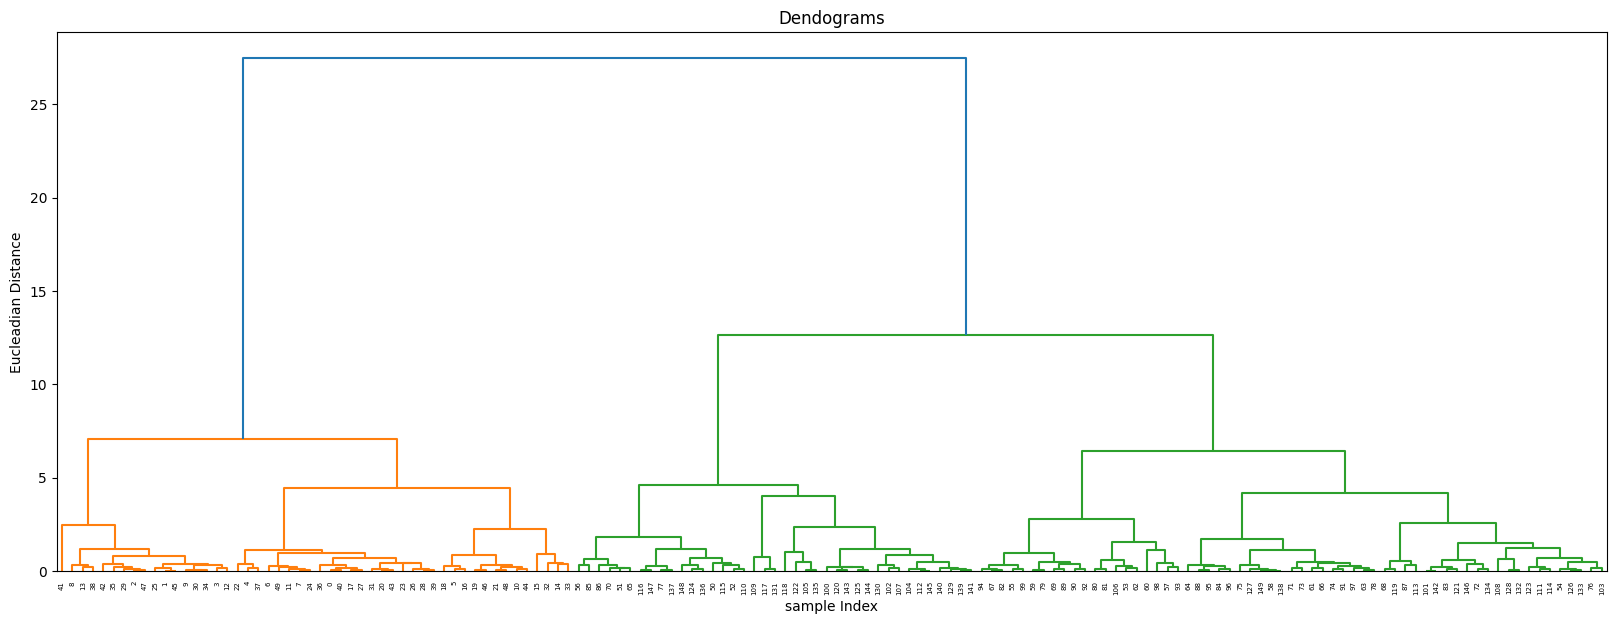

In [19]:
## DendoGram
import scipy.cluster.hierarchy as sc

plt.figure(figsize=(20,7))
plt.title("Dendograms")

sc.dendrogram(sc.linkage(scaled_pca_data, method='ward'))
plt.xlabel("sample Index")
plt.ylabel("Eucleadian Distance")
plt.show()

In [20]:
from sklearn.cluster import AgglomerativeClustering

In [22]:
cluster = AgglomerativeClustering(n_clusters=2)
cluster.fit(scaled_pca_data)

AgglomerativeClustering()

In [23]:
cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

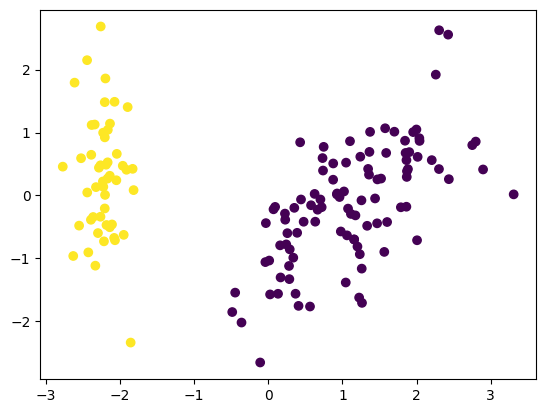

In [24]:
plt.scatter(scaled_pca_data[:,0], scaled_pca_data[:,1], c = cluster.labels_);

In [25]:
## Silhoute score
from sklearn.metrics import silhouette_score

In [26]:
silhouette_coefficients = []

for k in range(2,11):
    agglo = AgglomerativeClustering(n_clusters=k)
    agglo.fit(scaled_pca_data)
    score = silhouette_score(scaled_pca_data, agglo.labels_)
    silhouette_coefficients.append(score)

In [27]:
silhouette_coefficients

[0.6145202036230452,
 0.511059598876619,
 0.4487350420958893,
 0.4041689631006268,
 0.3672112889583074,
 0.37068206789126673,
 0.3930552606912112,
 0.4183694466469872,
 0.40542056288894907]

## DBSCAN CLUSTERING (DENSITY BASED)

In [28]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline

In [29]:
X,y = make_moons(n_samples= 250, noise= 0.05)

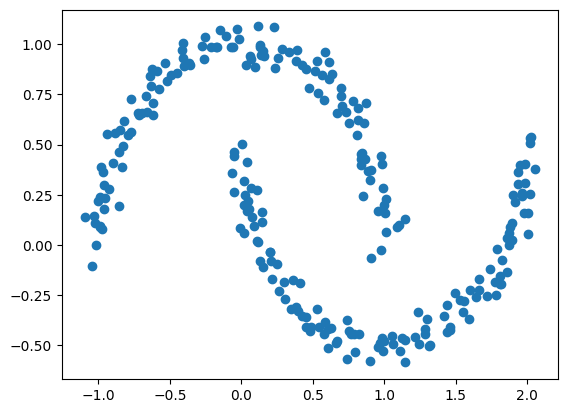

In [33]:
plt.scatter(X[:,0], X[:,1])

In [34]:
## SCALING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [35]:
X_scaled = scaler.fit_transform(X)

In [36]:
## algorithm
dbscan = DBSCAN(eps= 0.5)

In [37]:
dbscan.fit(X_scaled)

DBSCAN()

In [38]:
dbscan.labels_

array([0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0], dtype=int64)

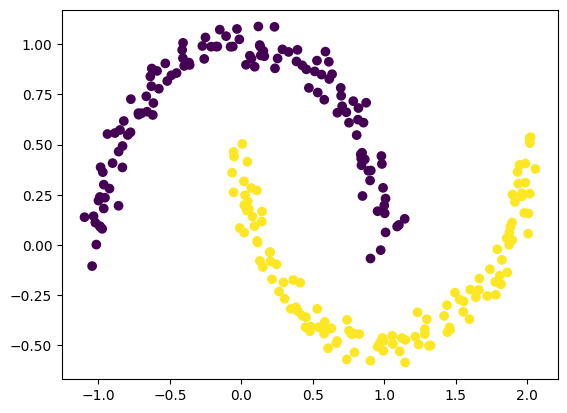

In [39]:
plt.scatter(X[:,0], X[:,1], c= dbscan.labels_);